Initialise PySpark

In [1]:
!pip3 install pyspark

In [3]:
import pyspark
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("Tutorial1_CN7030_Week2_AirlineDelays") \
                            .master("local[*]")\
                            .config("spark.some.config.option", "some-value") \
                            .getOrCreate()

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
# import file titled Airline_Delay_Cause in my Google Drive

df = spark.read.csv("/content/drive/MyDrive/CN7030 - Machine Learning on Big Data (T2)/Labs/Week 2 Lab - Data Visualisation with PySpark - Wednesday 11th February/Airline_Delay_Cause.csv", header=True, inferSchema=True)

View Dataset

In [13]:
# show table

df.show(10)

+----+-----+-------+-------------+-------+--------------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|year|month|carrier| carrier_name|airport|        airport_name|arr_flights|arr_del15|carrier_ct|weather_ct|nas_ct|security_ct|late_aircraft_ct|arr_cancelled|arr_diverted|arr_delay|carrier_delay|weather_delay|nas_delay|security_delay|late_aircraft_delay|
+----+-----+-------+-------------+-------+--------------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|2025|    1|     G4|Allegiant Air|    ELM|Elmira/Corning, N...|         30|        0|       0.0|       0.0|   0.0|        0.0|             0.0|            0|           0|        0|            0|            0|        0|             0|     

In [14]:
# show schema

df.printSchema()

root
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- carrier: string (nullable = true)
 |-- carrier_name: string (nullable = true)
 |-- airport: string (nullable = true)
 |-- airport_name: string (nullable = true)
 |-- arr_flights: integer (nullable = true)
 |-- arr_del15: integer (nullable = true)
 |-- carrier_ct: double (nullable = true)
 |-- weather_ct: double (nullable = true)
 |-- nas_ct: double (nullable = true)
 |-- security_ct: double (nullable = true)
 |-- late_aircraft_ct: double (nullable = true)
 |-- arr_cancelled: integer (nullable = true)
 |-- arr_diverted: integer (nullable = true)
 |-- arr_delay: integer (nullable = true)
 |-- carrier_delay: integer (nullable = true)
 |-- weather_delay: integer (nullable = true)
 |-- nas_delay: integer (nullable = true)
 |-- security_delay: integer (nullable = true)
 |-- late_aircraft_delay: integer (nullable = true)



In [16]:
# number of rows

df.count()

398233

Preprocessing

In [20]:
# check for null values in each column

from pyspark.sql.functions import col, sum
import pandas as pd

print("NULL CHECK")

null_counts = df.select([sum(col(c).isNull().cast("int")).alias(c) for c in df.columns])

null_counts.show()

NULL CHECK
+----+-----+-------+------------+-------+------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|year|month|carrier|carrier_name|airport|airport_name|arr_flights|arr_del15|carrier_ct|weather_ct|nas_ct|security_ct|late_aircraft_ct|arr_cancelled|arr_diverted|arr_delay|carrier_delay|weather_delay|nas_delay|security_delay|late_aircraft_delay|
+----+-----+-------+------------+-------+------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|   0|    0|      0|           0|      0|           0|        657|      950|       657|       657|   657|        657|             657|          657|         657|      657|          657|          657|      657|           657|                657|
+----+---

In [21]:
# fill missing values with appropriate default values

from pyspark.sql.functions import when, col

print("Filling missing values:")

fill_values = {col_name: 0 if dtype.startswith("int") \
                or dtype.startswith("double") \
                else "Unknown"\
                for col_name, dtype in df.dtypes}

df_filled = df.fillna(fill_values)

df_filled.show(5)

Filling missing values:
+----+-----+-------+-------------+-------+--------------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|year|month|carrier| carrier_name|airport|        airport_name|arr_flights|arr_del15|carrier_ct|weather_ct|nas_ct|security_ct|late_aircraft_ct|arr_cancelled|arr_diverted|arr_delay|carrier_delay|weather_delay|nas_delay|security_delay|late_aircraft_delay|
+----+-----+-------+-------------+-------+--------------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|2025|    1|     G4|Allegiant Air|    ELM|Elmira/Corning, N...|         30|        0|       0.0|       0.0|   0.0|        0.0|             0.0|            0|           0|        0|            0|            0|      

In [22]:
# convert all columns containing doubles and floats to an integer
from pyspark.sql.functions import col, round
from pyspark.sql.types import DoubleType, FloatType, IntegerType

for c in df.columns:

    if isinstance(df.schema[c].dataType, (DoubleType, FloatType)):
        df = df.withColumn(c, round(col(c)).cast(IntegerType()))

df.printSchema()

df.show()

root
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- carrier: string (nullable = true)
 |-- carrier_name: string (nullable = true)
 |-- airport: string (nullable = true)
 |-- airport_name: string (nullable = true)
 |-- arr_flights: integer (nullable = true)
 |-- arr_del15: integer (nullable = true)
 |-- carrier_ct: integer (nullable = true)
 |-- weather_ct: integer (nullable = true)
 |-- nas_ct: integer (nullable = true)
 |-- security_ct: integer (nullable = true)
 |-- late_aircraft_ct: integer (nullable = true)
 |-- arr_cancelled: integer (nullable = true)
 |-- arr_diverted: integer (nullable = true)
 |-- arr_delay: integer (nullable = true)
 |-- carrier_delay: integer (nullable = true)
 |-- weather_delay: integer (nullable = true)
 |-- nas_delay: integer (nullable = true)
 |-- security_delay: integer (nullable = true)
 |-- late_aircraft_delay: integer (nullable = true)

+----+-----+-------+-------------+-------+--------------------+-----------+--------

In [23]:
# rules
# if column titled arr_flights is missing, assume there are 0 flights and set arr_flights to 0
from pyspark.sql.functions import col, when

flight_col = "arr_flights"

if flight_col in df.columns:

    df = df.withColumn(flight_col, when(col(flight_col).isNull(), 0).otherwise(col(flight_col)))

    # when there are 0 flights, delays/counts should also be 0
    flight_related_metrics = [
        'arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct', 'security_ct',
        'late_aircraft_ct', 'arr_cancelled', 'arr_diverted', 'arr_delay',
        'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay',
        'late_aircraft_delay'
    ]

    for c in flight_related_metrics:
        if c in df.columns:
            df = df.withColumn(
                c,
                when((col(flight_col) == 0) & col(c).isNull(), 0).otherwise(col(c))
            )


Basic Filtering / Querying of Data

In [24]:
# view arr_diverted that are more than 100
df.filter(df.arr_diverted > 100).show()

# count the number of rows
df.filter(df.arr_diverted > 100).count()

+----+-----+-------+--------------------+-------+--------------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|year|month|carrier|        carrier_name|airport|        airport_name|arr_flights|arr_del15|carrier_ct|weather_ct|nas_ct|security_ct|late_aircraft_ct|arr_cancelled|arr_diverted|arr_delay|carrier_delay|weather_delay|nas_delay|security_delay|late_aircraft_delay|
+----+-----+-------+--------------------+-------+--------------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|2024|   12|     AA|American Airlines...|    DFW|Dallas/Fort Worth...|      13622|     3036|       796|       161|   935|         12|            1133|          346|         149|   303265|        95737|        26955|  

65

In [27]:
# view arr_diverted that are more than 100 and security_delay is less than 100
df.filter((df.arr_diverted > 100) & (df.security_delay < 100)).show()

#count the number of rows
df.filter((df.arr_diverted > 100) & (df.security_delay < 100)).count()

+----+-----+-------+--------------------+-------+--------------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|year|month|carrier|        carrier_name|airport|        airport_name|arr_flights|arr_del15|carrier_ct|weather_ct|nas_ct|security_ct|late_aircraft_ct|arr_cancelled|arr_diverted|arr_delay|carrier_delay|weather_delay|nas_delay|security_delay|late_aircraft_delay|
+----+-----+-------+--------------------+-------+--------------------+-----------+---------+----------+----------+------+-----------+----------------+-------------+------------+---------+-------------+-------------+---------+--------------+-------------------+
|2023|    8|     DL|Delta Air Lines N...|    ATL|Atlanta, GA: Hart...|      19716|     3416|       929|       170|   936|          1|            1381|          475|         125|   303248|       110115|        22089|  

28

## 1. How have overall flight delays changed over time?


Plot arr_del15 / arr_flights as a line chart by year and month.

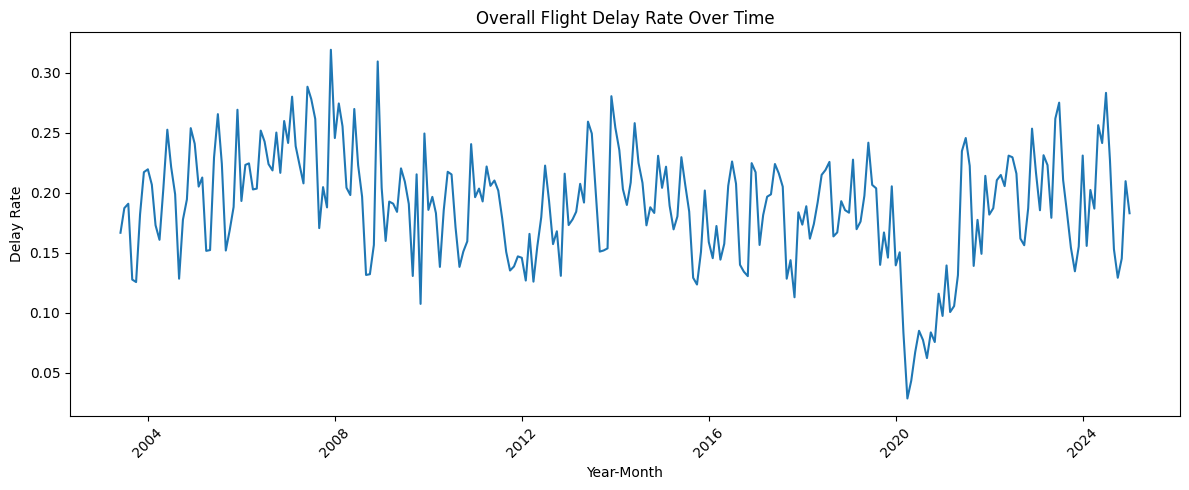

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# create PySpark DataFrame from Pandas DataFrame
df_pd = df.toPandas()

# aggregate by year & month
monthly = (
    df_pd.groupby(["year", "month"], as_index=False)
      .agg({"arr_del15": "sum", "arr_flights": "sum"})
)

# create date column
monthly["date"] = pd.to_datetime(dict(year=monthly.year,
                                      month=monthly.month,
                                      day=1))

# calculate delay rate
monthly["delay_rate"] = monthly["arr_del15"] / monthly["arr_flights"]

monthly = monthly.sort_values("date")

# plot line chart
plt.figure(figsize=(12, 5))
plt.plot(monthly["date"], monthly["delay_rate"])
plt.xlabel("Year-Month")
plt.ylabel("Delay Rate")
plt.title("Overall Flight Delay Rate Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2. Which airlines have the highest percentage of delayed flights?

Create a bar chart of average delay rate per carrier_name.

carrier_name
ATA Airlines d/b/a ATA                       0.211270
Air Wisconsin Airlines Corp                  0.185621
AirTran Airways Corporation                  0.199380
Alaska Airlines Inc.                         0.167641
Alaska Airlines Network                      0.170856
Allegiant Air                                0.202595
Aloha Airlines Inc.                          0.114339
America West Airlines Inc.                   0.225039
American Airlines Inc.                       0.225930
American Airlines Network                    0.221010
American Eagle Airlines Inc.                 0.228205
Atlantic Coast Airlines                      0.222922
Atlantic Southeast Airlines                  0.256382
Cape Air                                     0.082905
Comair Inc.                                  0.230587
Commutair Aka Champlain Enterprises, Inc.    0.238647
CommuteAir LLC dba CommuteAir                0.194866
Compass Airlines                             0.169335
Continental Air

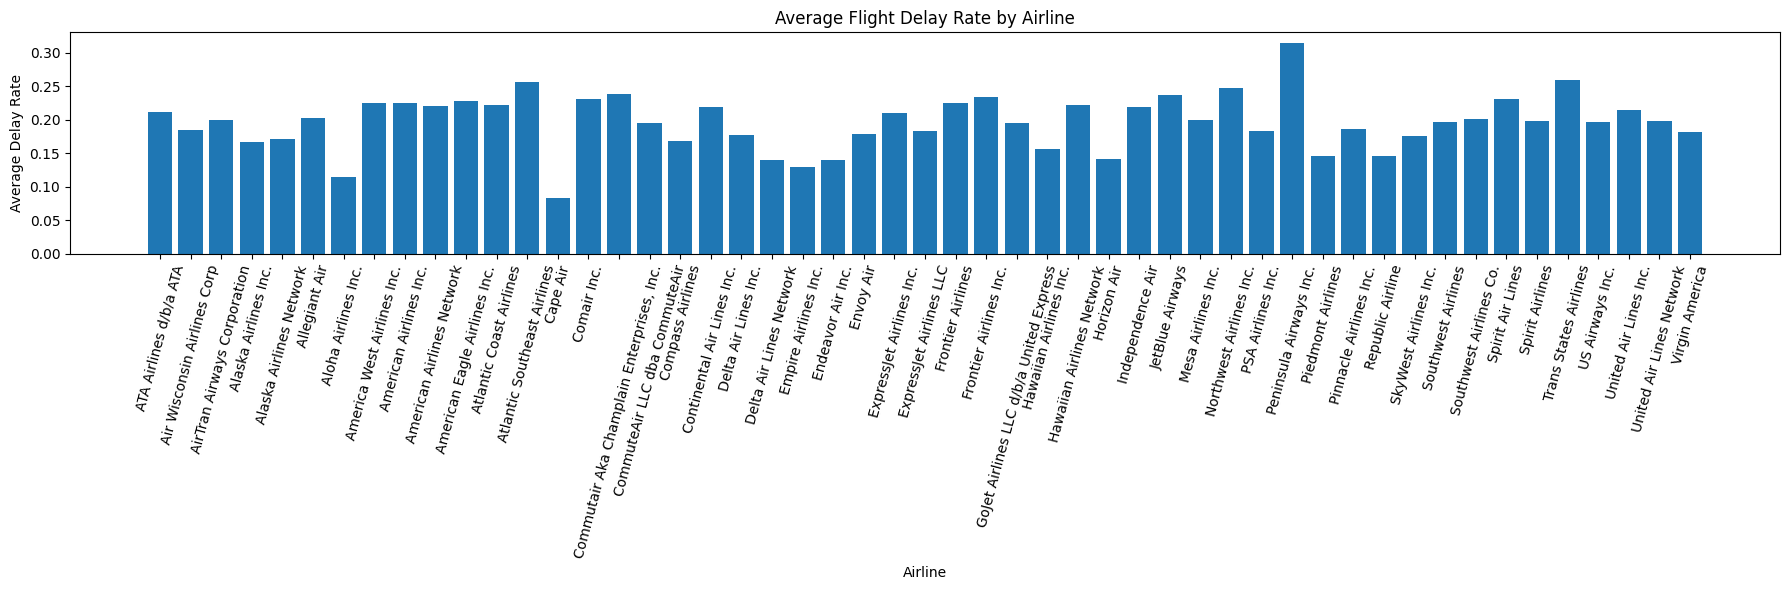

In [29]:
import pandas as pd

import matplotlib.pyplot as plt

# calculate delay rate
df_pd["delay_rate"] = df_pd["arr_del15"] / df_pd["arr_flights"]

# calculate average delay rate for each airline
airline_delay_rates = df_pd.groupby("carrier_name")["delay_rate"].mean()

# show airline_delay_rates as a table
print(airline_delay_rates)

# plot bar chart
plt.figure(figsize=(18, 6))
plt.bar(airline_delay_rates.index, airline_delay_rates.values)

plt.xlabel("Airline")
plt.ylabel("Average Delay Rate")
plt.title("Average Flight Delay Rate by Airline")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

## 3. Which airlines experience the most carrier‑caused delays?

Visualise carrier_ct (carrier-caused delay count) per airline.

Carrier-Caused Delays by Airline:
carrier_name
SkyWest Airlines Inc.                        60774409
Southwest Airlines Co.                       38737840
American Airlines Inc.                       35368694
American Airlines Network                    33095989
Delta Air Lines Inc.                         32058722
Southwest Airlines                           28147225
Delta Air Lines Network                      27798944
ExpressJet Airlines Inc.                     27393505
JetBlue Airways                              25590200
United Air Lines Inc.                        22778309
American Eagle Airlines Inc.                 17019505
United Air Lines Network                     16107789
Mesa Airlines Inc.                           14809825
Atlantic Southeast Airlines                  13837566
US Airways Inc.                              13704265
Northwest Airlines Inc.                      11745027
Comair Inc.                                   8415020
Envoy Air                          

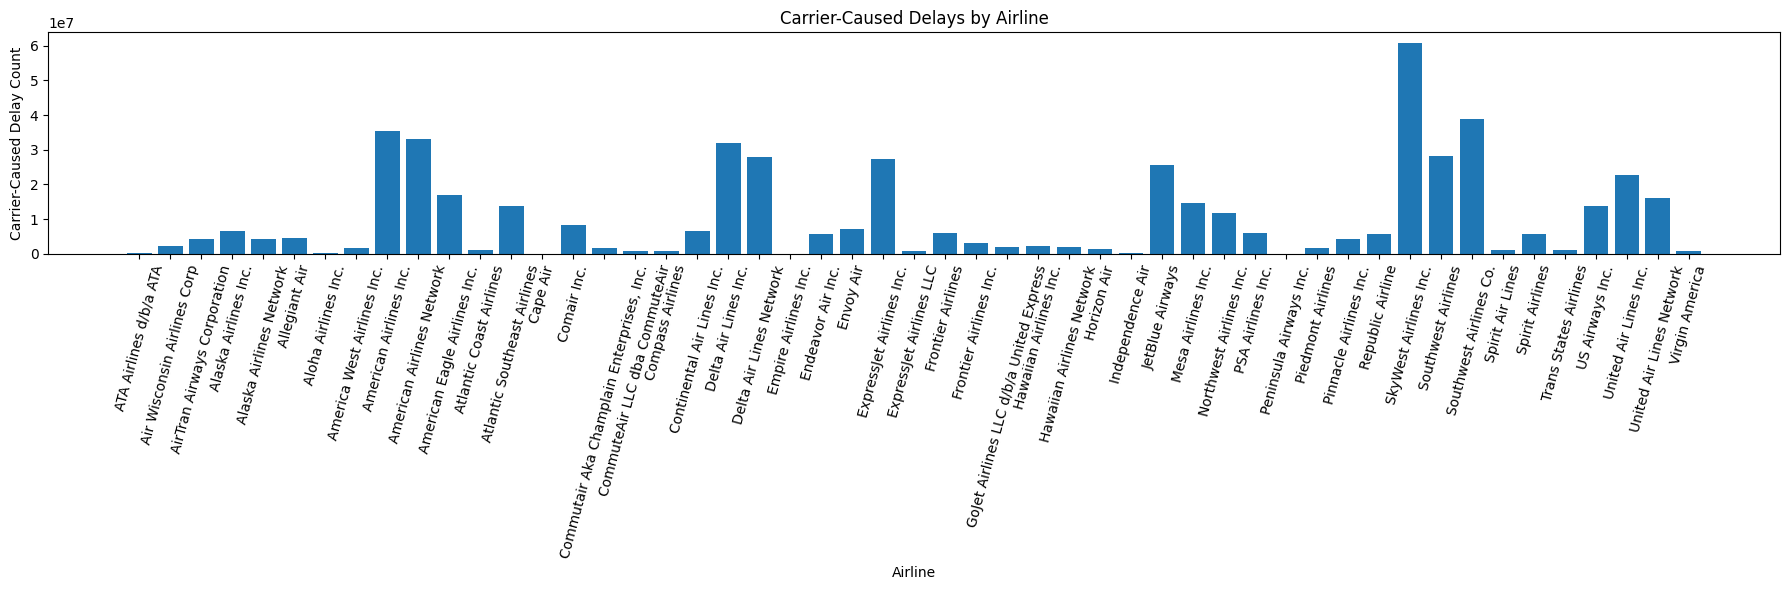

In [30]:
import pandas as pd

import matplotlib.pyplot as plt

# calculate the total sum of carrier-caused delays per airline
airline_carrier_delays = df_pd.groupby("carrier_name")["carrier_delay"].sum()

# show carrier-caused delays as a table in descending order
print("Carrier-Caused Delays by Airline:")
print(airline_carrier_delays.sort_values(ascending=False))

# visualise carrier_ct (carrier-caused delay count) per airline in descending order
plt.figure(figsize=(18, 6))
plt.bar(airline_carrier_delays.index, airline_carrier_delays.values)

plt.xlabel("Airline")
plt.ylabel("Carrier-Caused Delay Count")
plt.title("Carrier-Caused Delays by Airline")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

## 4. Which airports have the highest delay rates?

Scatter or bar chart of delay rate vs airport, sorted by highest rates

Delay Rates by Airport:
                                          airport_name  arr_del15  \
447  Youngstown/Warren, OH: Youngstown-Warren Regional        2.0   
317         Pinehurst/Southern Pines, NC: Moore County      133.0   
418                     Unalaska, AK: Unalaska Airport      770.0   
409                        Topeka, KS: Topeka Regional      164.0   
76                      Cold Bay, AK: Cold Bay Airport       90.0   
441                         Wilmington, DE: New Castle      688.0   
357                            Salem, OR: McNary Field      281.0   
234                 Macon, GA: Middle Georgia Regional     2050.0   
3                      Aguadilla, PR: Rafael Hernandez     9692.0   
398                       Stockton, CA: Stockton Metro      619.0   
326  Presque Isle/Houlton, ME: Presque Isle Interna...     1078.0   
290  North Bend/Coos Bay, OR: Southwest Oregon Regi...     2698.0   
332               Punta Gorda, FL: Punta Gorda Airport    11681.0   
204  Kinst

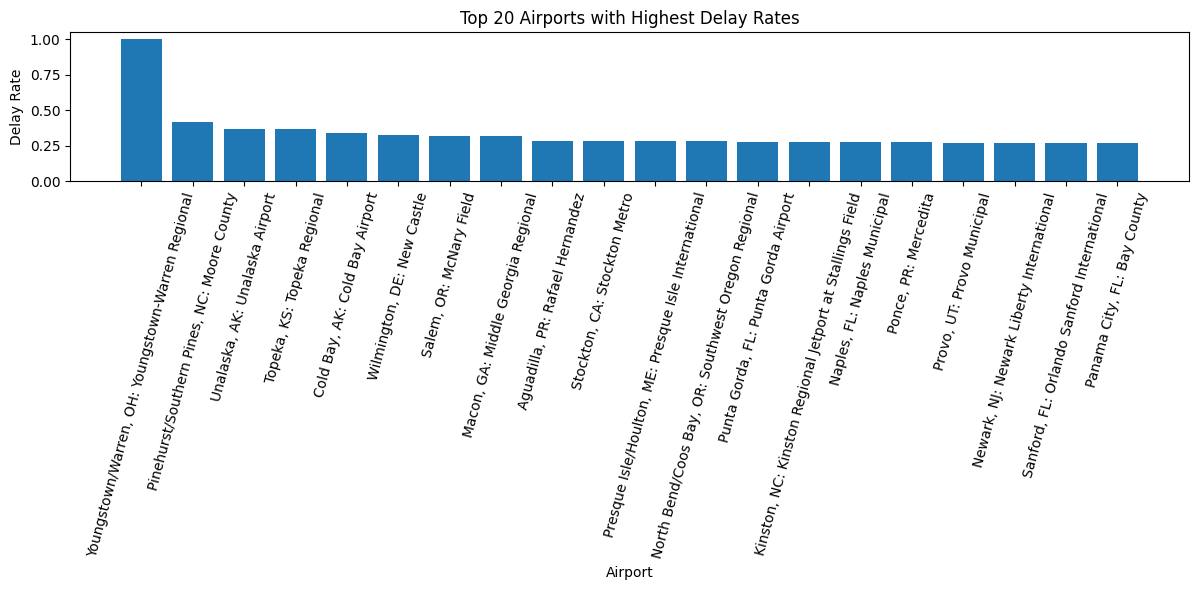

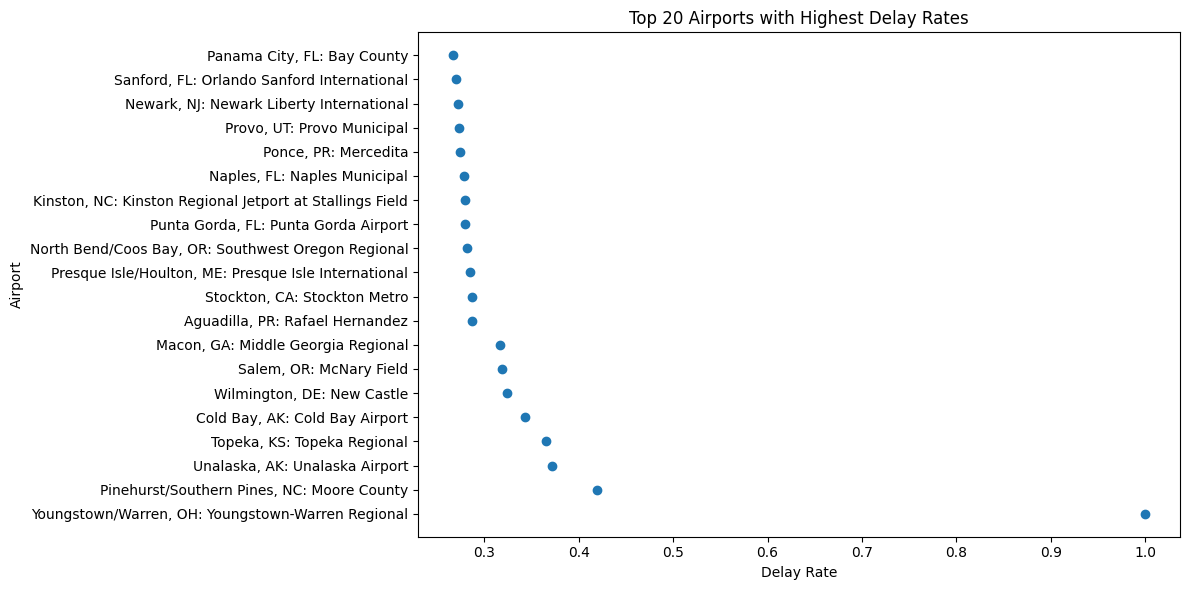

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# aggregate delays and flights per airport
airport_delays = (
    df_pd.groupby("airport_name", as_index=False)
      .agg({
          "arr_del15": "sum",
          "arr_flights": "sum"
      })
)

# calculate delay rate
airport_delays["delay_rate"] = airport_delays["arr_del15"] / airport_delays["arr_flights"]

# sort and select Top 20
top20 = airport_delays.sort_values("delay_rate", ascending=False).head(20)

# show airport_delays as a table in descending order
print("Delay Rates by Airport:")
print(top20)

# plot bar chart
plt.figure(figsize=(12, 6))
plt.bar(top20["airport_name"], top20["delay_rate"])

plt.xlabel("Airport")
plt.ylabel("Delay Rate")
plt.title("Top 20 Airports with Highest Delay Rates")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

# plot scatter graph

plt.figure(figsize=(12, 6))
plt.scatter(top20["delay_rate"], top20["airport_name"])

plt.xlabel("Delay Rate")
plt.ylabel("Airport")
plt.title("Top 20 Airports with Highest Delay Rates")
plt.tight_layout()
plt.show()

## 5. What are the dominant causes of delays across all flights?

Stacked bar chart: cause distribution percentage by year

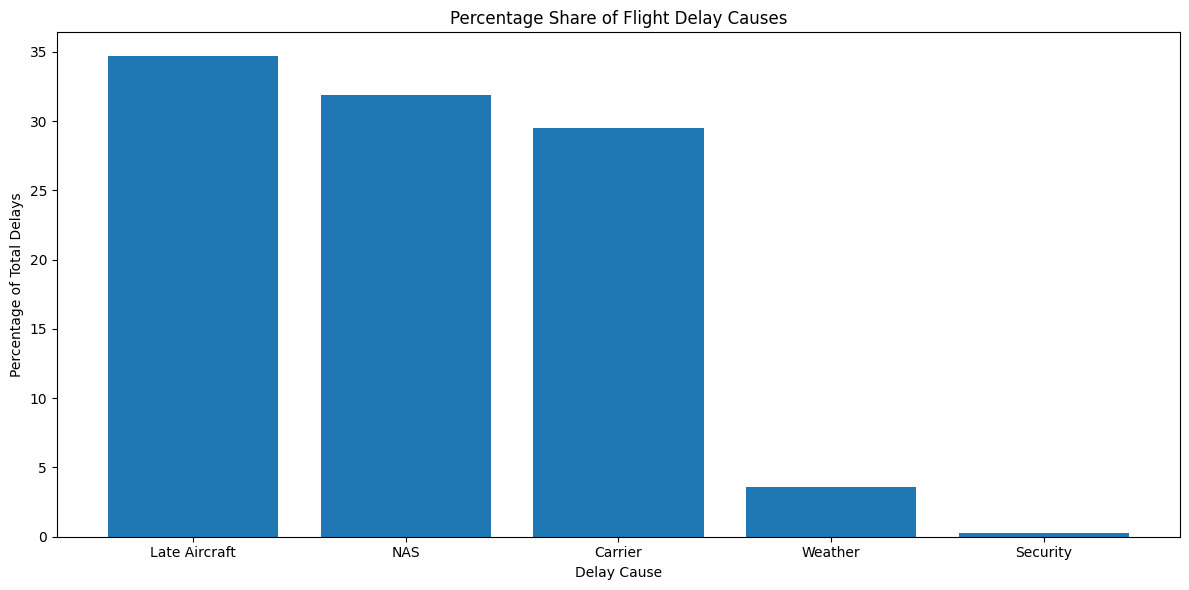

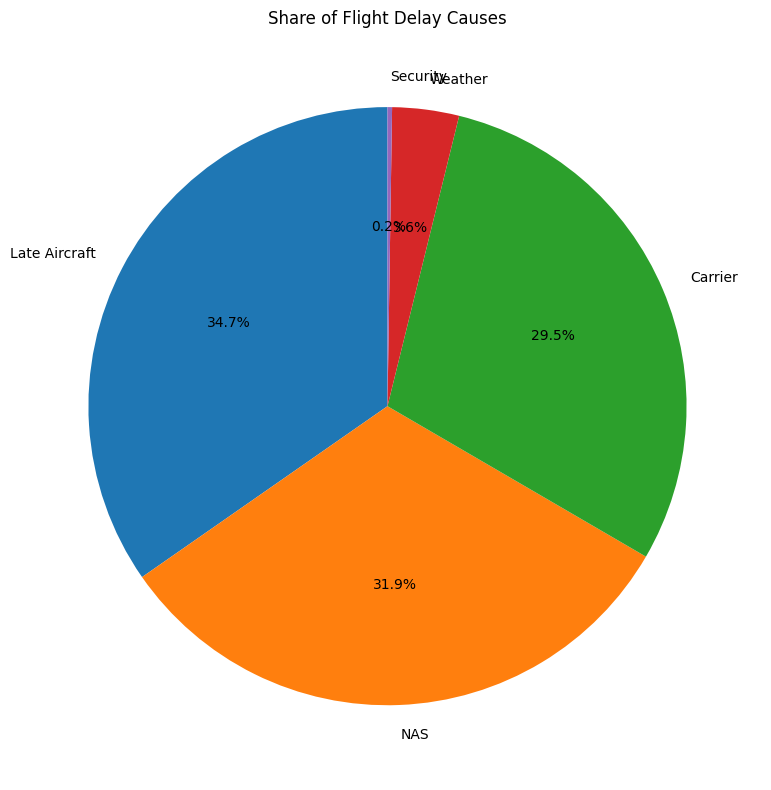

In [36]:
import pandas as pd

import matplotlib.pyplot as plt

from pyspark.sql import functions as F

# calculate the total sum delays by cause
causes = {
    "Carrier": df.agg(F.sum("carrier_ct")).collect()[0][0],
    "Weather": df.agg(F.sum("weather_ct")).collect()[0][0],
    "NAS": df.agg(F.sum("nas_ct")).collect()[0][0],
    "Security": df.agg(F.sum("security_ct")).collect()[0][0],
    "Late Aircraft": df.agg(F.sum("late_aircraft_ct")).collect()[0][0]
}

cause_df = pd.DataFrame(list(causes.items()), columns=["Cause", "Total"])

# calculate the percentage
total_delays = cause_df["Total"].sum()
cause_df["Percentage"] = (cause_df["Total"] / total_delays) * 100

# sort in descending order
cause_df = cause_df.sort_values("Percentage", ascending=False)

# plot bar chart
plt.figure(figsize=(12, 6))
plt.bar(cause_df["Cause"], cause_df["Percentage"])

plt.xlabel("Delay Cause")
plt.ylabel("Percentage of Total Delays")
plt.title("Percentage Share of Flight Delay Causes")
plt.tight_layout()
plt.show()

# plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    cause_df["Total"],
    labels=cause_df["Cause"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Share of Flight Delay Causes")
plt.tight_layout()
plt.show()

Stacked bar chart showing delay-cause percentages by year

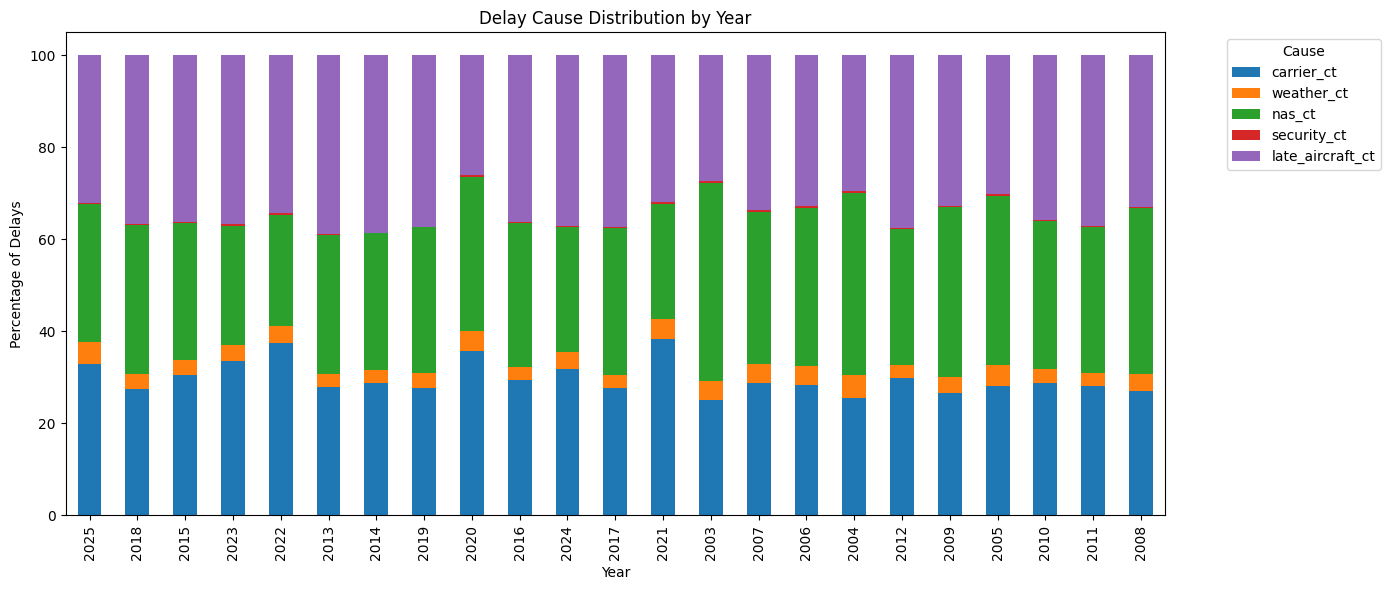

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import functions as F

# sum delay causes by year using PySpark and then convert to Pandas
yearly_spark = df.groupby("year").agg(
    F.sum("carrier_ct").alias("carrier_ct"),
    F.sum("weather_ct").alias("weather_ct"),
    F.sum("nas_ct").alias("nas_ct"),
    F.sum("security_ct").alias("security_ct"),
    F.sum("late_aircraft_ct").alias("late_aircraft_ct")
)
yearly = yearly_spark.toPandas()


yearly = yearly.set_index('year')

# convert to percentages
yearly_pct = yearly.div(yearly.sum(axis=1), axis=0) * 100

# plot stacked bar chart
plt.figure(figsize=(14, 6))
yearly_pct.plot(kind="bar", stacked=True, ax=plt.gca()) # Use plt.gca() to ensure it plots on the current figure

plt.xlabel("Year")
plt.ylabel("Percentage of Delays")
plt.title("Delay Cause Distribution by Year")
plt.legend(title="Cause", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

## 6. How do causes vary by season?

Group by month: use a multi‑line chart showing counts for each cause

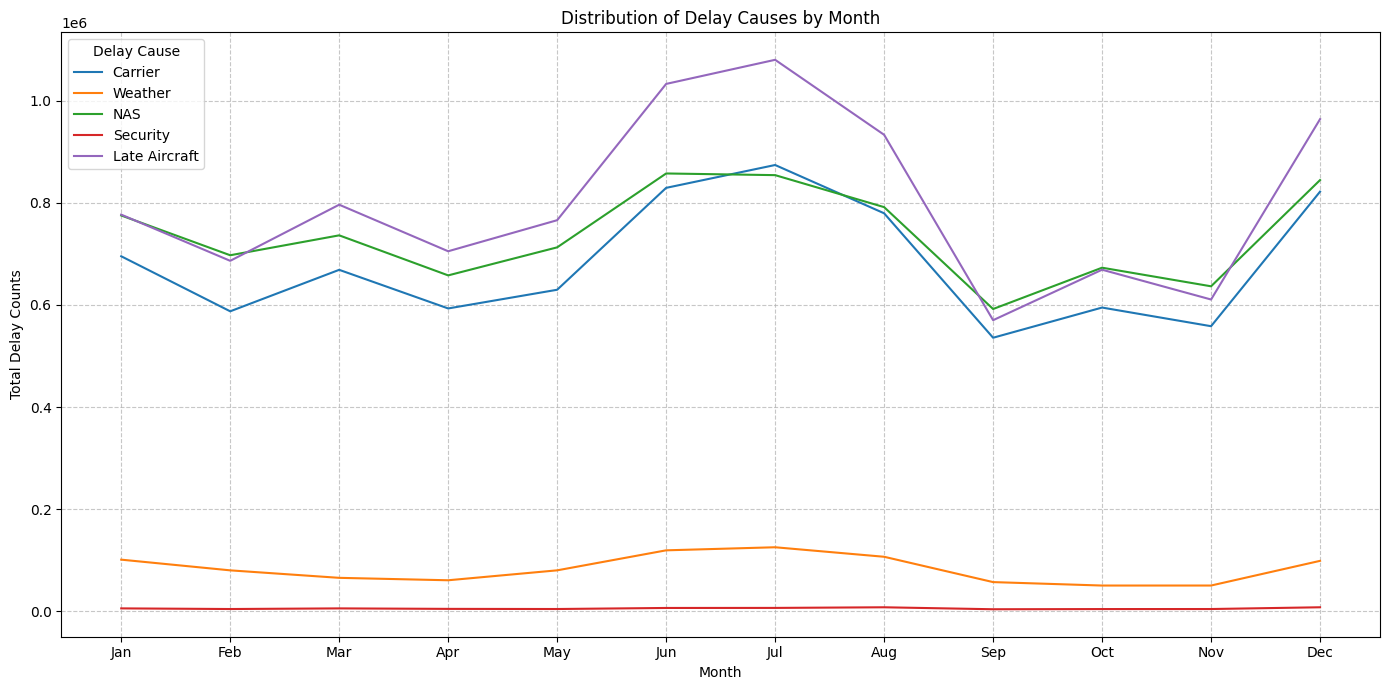

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F

# group by month and sum the delay causes
monthly_causes_spark = df.groupby("month").agg(
    F.sum("carrier_ct").alias("Carrier"),
    F.sum("weather_ct").alias("Weather"),
    F.sum("nas_ct").alias("NAS"),
    F.sum("security_ct").alias("Security"),
    F.sum("late_aircraft_ct").alias("Late Aircraft")
)

# convert to Pandas DataFrame
monthly_causes = monthly_causes_spark.toPandas()

# melt the DataFrame for easier plotting with seaborn
monthly_causes_melted = monthly_causes.melt('month', var_name='Cause Type', value_name='Total Delays')

# plot multi-line chart
plt.figure(figsize=(14, 7))
sns.lineplot(x='month', y='Total Delays', hue='Cause Type', data=monthly_causes_melted)
plt.title('Distribution of Delay Causes by Month')
plt.xlabel('Month')
plt.ylabel('Total Delay Counts')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Delay Cause')
plt.tight_layout()
plt.show()

## 7. Which months have the highest and lowest delay percentages?

Use a line chart or boxplot grouped by month to reveal seasonality

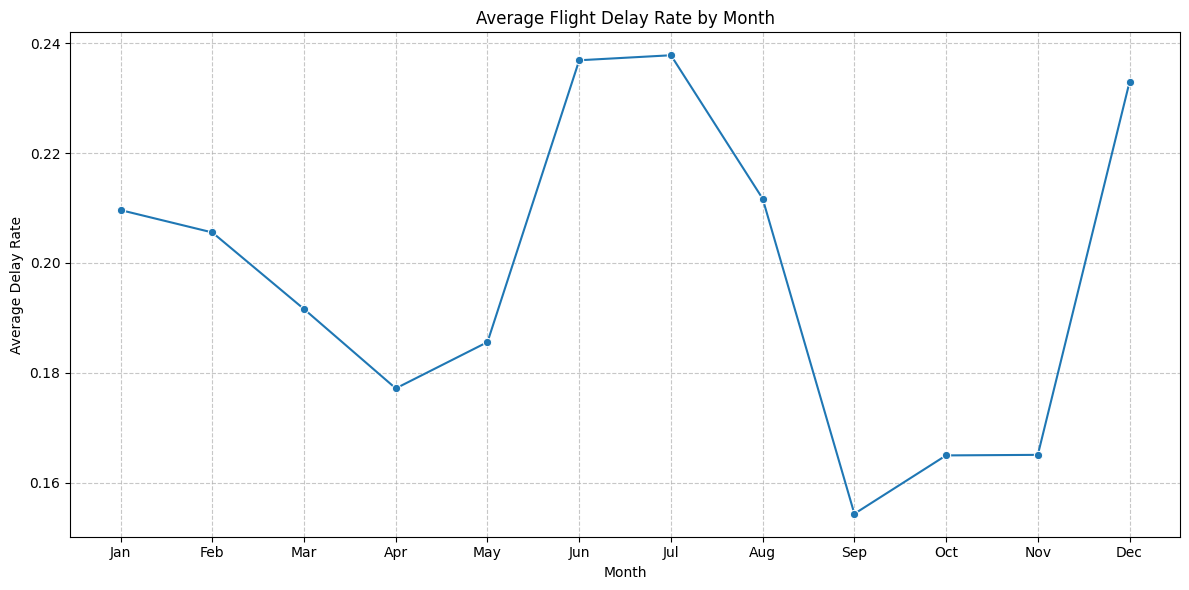

In [44]:
import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

# group by month and calculate the average delay rate
monthly_avg_delay_rate = df_pd.groupby('month')['delay_rate'].mean().reset_index()

# convert month numbers to names
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_avg_delay_rate['month_name'] = monthly_avg_delay_rate['month'].map(lambda x: month_names[x-1])

# sort month number in chronological order
monthly_avg_delay_rate = monthly_avg_delay_rate.sort_values('month')

# plot the line chart
plt.figure(figsize=(12, 6))
sns.lineplot(x='month_name', y='delay_rate', data=monthly_avg_delay_rate, marker='o')
plt.title('Average Flight Delay Rate by Month')
plt.xlabel('Month')
plt.ylabel('Average Delay Rate')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

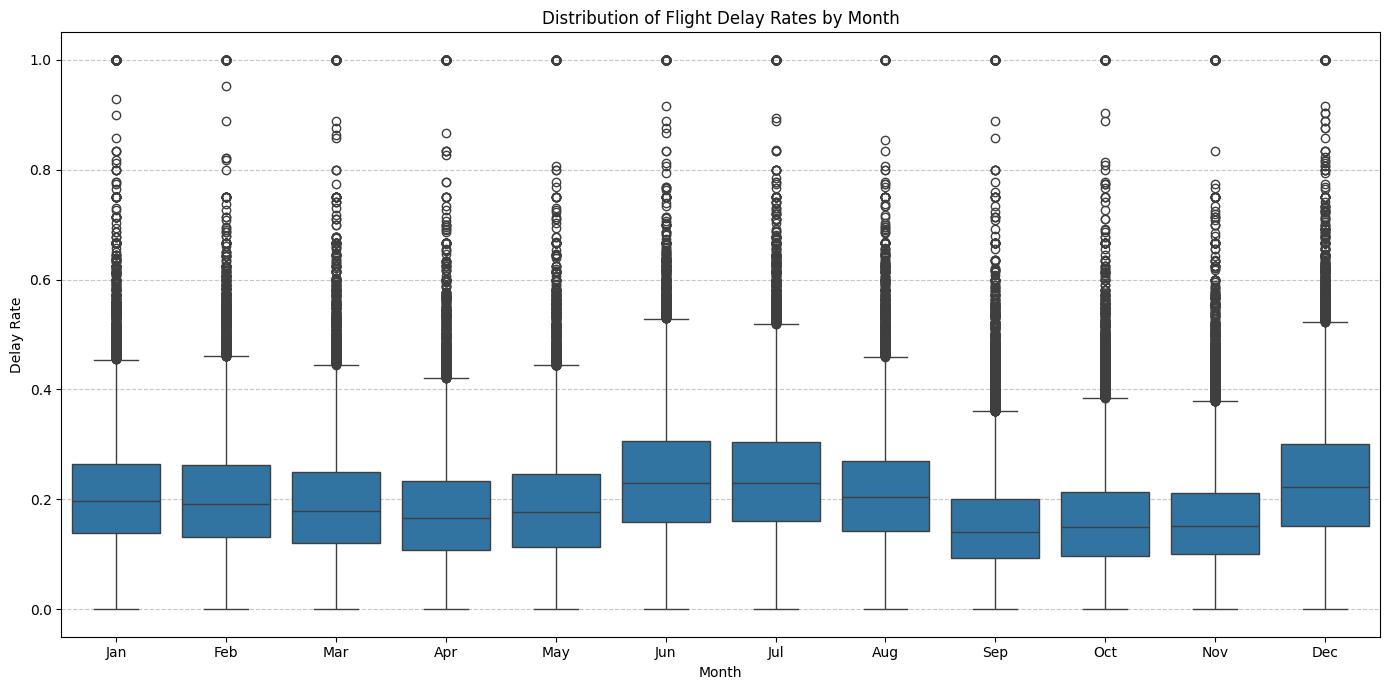

In [46]:
# plot the boxplot

plt.figure(figsize=(14, 7))
sns.boxplot(x='month_name', y='delay_rate', data=df_pd.sort_values('month'))
plt.title('Distribution of Flight Delay Rates by Month')
plt.xlabel('Month')
plt.ylabel('Delay Rate')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()